[row 1/10] m0=0.7000 | elapsed=238.9s | eta=2150.4s
[row 2/10] m0=0.7111 | elapsed=479.3s | eta=1917.2s
[row 3/10] m0=0.7222 | elapsed=700.6s | eta=1634.7s
[row 4/10] m0=0.7333 | elapsed=888.0s | eta=1332.0s
[row 5/10] m0=0.7444 | elapsed=1071.6s | eta=1071.6s
[row 6/10] m0=0.7556 | elapsed=1235.5s | eta=823.7s
[row 7/10] m0=0.7667 | elapsed=1385.8s | eta=593.9s
[row 8/10] m0=0.7778 | elapsed=1525.9s | eta=381.5s
[row 9/10] m0=0.7889 | elapsed=1658.3s | eta=184.3s
[row 10/10] m0=0.8000 | elapsed=1795.8s | eta=0.0s


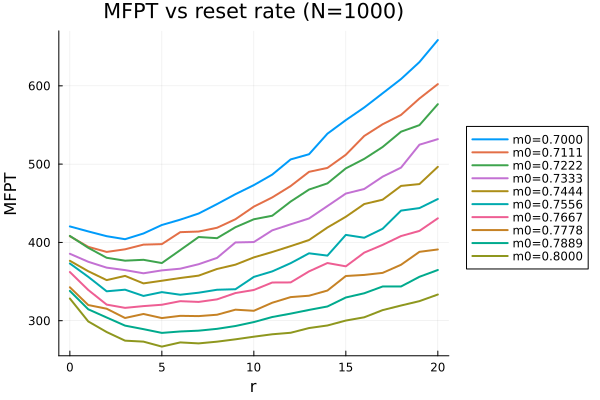

In [1]:
include(joinpath(dirname(pwd()), "src", "VoterResetting.jl"))
using .VoterResetting
using Plots
using Base.Threads
using Printf

# Python-convention scaling: reset contribution in Gillespie is r/N.
N = 1000
r_values = LinRange(0, 20, 21)
m0_values = LinRange(0.7, 0.8, 10)
nsamples = 10000
total = length(m0_values) * length(r_values)

function mean_fpt_fast(N::Int, m0::Float64, r_mc::Float64, nsamples::Int)
    r_ct = r_mc / N
    vals = Vector{Float64}(undef, nsamples)

    Threads.@threads for k in 1:nsamples
        vals[k] = VoterResetting.simulate_fpt_all_to_all_trajectory(
            N,
            m0,
            r_ct,
            VoterResetting.delta_reset(m0),
            :either,
        )
    end

    return sum(vals) / nsamples
end

mfpt = zeros(length(m0_values), length(r_values))
start_time = time()

for (i, m0) in enumerate(m0_values)
    for (j, r) in enumerate(r_values)
        mfpt[i, j] = mean_fpt_fast(N, m0, r, nsamples)
    end

    done = i * length(r_values)
    elapsed = time() - start_time
    rate = done / max(elapsed, 1e-9)
    eta = (total - done) / max(rate, 1e-9)
    @printf("[row %d/%d] m0=%.4f | elapsed=%.1fs | eta=%.1fs\n", i, length(m0_values), m0, elapsed, eta)
    flush(stdout)
end

plot(
    r_values,
    mfpt';
    xlabel = "r",
    ylabel = "MFPT",
    title = "MFPT vs reset rate (N=1000)",
    label = reshape([@sprintf("m0=%.4f", m0) for m0 in m0_values], 1, :),
    legend = :outerright,
    linewidth = 2,
)